# 06 - K-Means Clustering of Pollution Profiles
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Group records by their pollutant composition, choose K from evidence rather than preference, and describe each cluster with neutral, number-backed language.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


In [2]:
import config as C
import data_utils as U
import preprocessing as P
import feature_engineering as FE
import clustering as KM
import figures as F
import viz as V
from IPython.display import display, Image

clean, *_ = P.clean(U.load_raw())
feat, _ = FE.build_features(clean)
polls = C.pollutant_columns(feat.columns)
print("clustering features taken from the data:", polls)

clustering features taken from the data: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']


## 1. Feature selection and preparation

Only measured pollutant concentrations are used. `AQI` is deliberately excluded:
it is a composite of the pollutants, so including it would cluster on a derived
value and double-count the same information.

In [3]:
X, scaler, used, raw = KM.build_matrix(feat, polls)
print(f"rows used            : {len(X):,} (records without missing values in the features)")
print(f"features standardised : {used}")
print("before scaling - means:")
display(raw.mean().round(2).to_frame("mean"))
print("after scaling - each column has mean 0 and unit variance:")
display(X.describe().loc[["mean", "std", "min", "max"]].round(2))

rows used            : 18,265 (records without missing values in the features)
features standardised : ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
before scaling - means:


,mean
PM2.5,250.60
PM10,299.44
NO,100.48
NO2,75.42
NOx,125.96
NH3,25.07
CO,5.00
SO2,49.84
O3,100.41


after scaling - each column has mean 0 and unit variance:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.73,-1.73,-1.74,-1.74,-1.74,-1.73,-1.73,-1.72,-1.74
max,1.73,1.73,1.72,1.72,1.71,1.73,1.73,1.73,1.73


### Why StandardScaler

K-Means assigns points to the nearest centroid using Euclidean distance. PM10
spans 0-600 while CO spans 0-10, so without scaling, PM10 alone would decide the
assignment and the other pollutants would be ignored.

## 2. Choosing K - elbow method and silhouette score

* **Inertia** = within-cluster sum of squares. It always falls as K grows, so the
  question is where the fall stops being informative (the "elbow").
* **Silhouette** = mean (b - a) / max(a, b) over points, where *a* is the mean
  distance to the point's own cluster and *b* the mean distance to the nearest
  other cluster. Above ~0.25 is usually read as weak structure; above 0.5 as
  clear structure.

In [4]:
k_table = KM.choose_k(X, C.K_RANGE)
display(k_table)
k_table.to_csv(C.PROCESSED_DIR / "k_selection_table.csv", index=False)
choice = KM.recommend_k(k_table)
for key, value in choice.items():
    print(f"{key:>18}: {value}")

,K,Inertia,Silhouette_Score,Clusters_Used,Evaluated_On
0,2,150577.68,0.0838,2,"6000 rows (silhouette), 18265 rows (inertia)"
1,3,142166.90,0.0728,3,"6000 rows (silhouette), 18265 rows (inertia)"
2,4,135388.48,0.0745,4,"6000 rows (silhouette), 18265 rows (inertia)"
3,5,130238.28,0.0730,5,"6000 rows (silhouette), 18265 rows (inertia)"
4,6,125960.17,0.0733,6,"6000 rows (silhouette), 18265 rows (inertia)"
5,7,121974.05,0.0750,7,"6000 rows (silhouette), 18265 rows (inertia)"
6,8,118453.34,0.0776,8,"6000 rows (silhouette), 18265 rows (inertia)"
7,9,115494.17,0.0754,9,"6000 rows (silhouette), 18265 rows (inertia)"
8,10,112655.61,0.0767,10,"6000 rows (silhouette), 18265 rows (inertia)"


   K_by_silhouette: 2
        silhouette: 0.0838
   K_by_elbow_rule: 4
        elbow_rule: first K where inertia improvement < 5%
          chosen_K: 2
         rationale: silhouette preferred; the elbow rule suggested a different K, which is reported as a disagreement rather than hidden


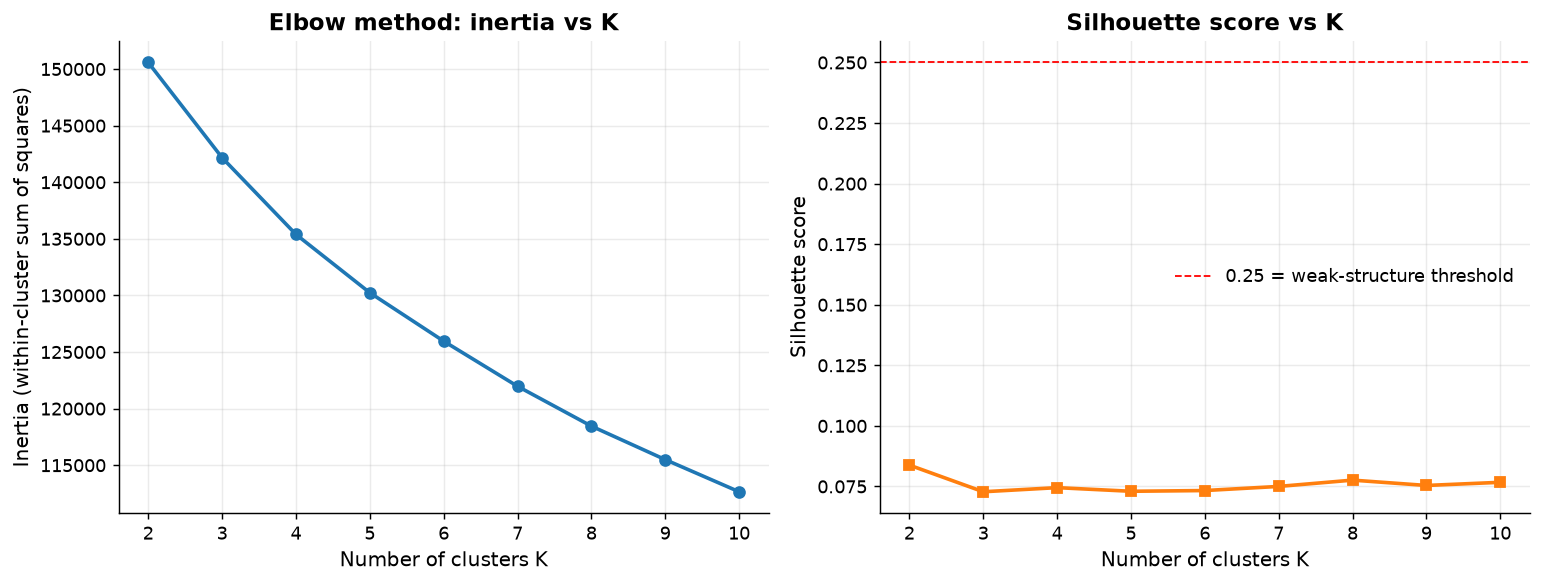

In [5]:
Image(F.clustering_k(k_table)["01_elbow_silhouette"])

### K is chosen from the evidence, and the disagreement is reported

The silhouette and the elbow rule do not have to agree. Here the rule that is
followed is stated in advance: **maximise the silhouette score**, with the elbow
reported as corroboration. If they disagree, the disagreement is printed rather
than hidden.

In [6]:
K = choice["chosen_K"]
print(f"selected K = {K} (silhouette {choice['silhouette']})")
sil_max = k_table["Silhouette_Score"].max()
print(f"highest silhouette over all tested K: {sil_max}")
print("conventional reading: < 0.25 weak / 0.25-0.5 moderate / > 0.5 distinct structure")

selected K = 2 (silhouette 0.0838)
highest silhouette over all tested K: 0.0838
conventional reading: < 0.25 weak / 0.25-0.5 moderate / > 0.5 distinct structure


## 3. Fit K-Means with the selected K

In [7]:
feat, model, scaler, used, centroids_z, centroids_raw = KM.fit(feat, polls, K)
print("inertia                 :", round(float(model.inertia_), 2))
print("iterations to converge  :", int(model.n_iter_))
print("cluster sizes           :", dict(pd.Series(model.labels_).value_counts()))
display(centroids_raw.round(2))
centroids_raw.to_csv(C.PROCESSED_DIR / "cluster_centroids_original_units.csv", index=False)

inertia                 : 150577.68
iterations to converge  : 21
cluster sizes           : {1: np.int64(9153), 0: np.int64(9112)}


,Cluster,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3
0,0,250.64,304.8,101.12,74.75,63.05,25.21,4.99,50.85,99.31
1,1,250.55,294.1,99.85,76.08,188.69,24.92,5.02,48.83,101.50


## 4. Cluster profile table

In [8]:
metrics = polls + [C.AQI_COL]
profile = KM.cluster_profile(feat, metrics)
display(profile[[c for c in ["Cluster", "Cluster_Size", "Share_%"] +
                 [f"Avg_{m}" for m in metrics] if c in profile.columns]])
profile.to_csv(C.CLUSTER_PROFILE_CSV, index=False)

,Cluster,Cluster_Size,Share_%,Avg_PM2.5,Avg_PM10,Avg_NO,Avg_NO2,Avg_NOx,Avg_NH3,Avg_CO,Avg_SO2,Avg_O3,Avg_AQI
0,0,9112,49.89,250.944,304.715,101.052,74.830,62.993,25.215,4.991,50.857,99.357,318.636
1,1,9153,50.11,250.253,294.194,99.913,75.999,188.653,24.916,5.014,48.819,101.452,316.379


In [9]:
desc = KM.describe_clusters(profile, metrics)
display(desc)
desc.to_csv(C.PROCESSED_DIR / "cluster_descriptions.csv", index=False)

,Cluster,Size,Relative_Position (1 = highest),Neutral_Description
0,0,9112,"PM2.5: rank 1, PM10: rank 1, NO: rank 1, NO2: rank 2",highest average PM2.5 among clusters
1,1,9153,"PM2.5: rank 2, PM10: rank 2, NO: rank 2, NO2: rank 1",lowest average PM2.5 among clusters


### Why the labels stay neutral

Words such as "dangerous" or "safe" require an external standard. This project
describes clusters only by their relative position on measured variables - for
example *highest average NOx among clusters* - and reports the numbers so the
reader can judge severity against whatever standard they care about.

## 5. Do the clusters mean anything?

Two extra checks that are often skipped: how much of the spread the clusters
actually explain, and whether the same partition appears with a different random
seed.

In [10]:
from sklearn.metrics import adjusted_rand_score
var_explained = 1 - model.inertia_ / (len(X) * X.values.var(axis=0).sum())
print(f"share of feature variance explained by the K={K} partition: "
      f"{100*var_explained:.2f}%")

alt = [KM.fit(feat.drop(columns=["Cluster", "PC1", "PC2"], errors="ignore"), polls, K,
              random_state=s)[1].labels_ for s in (7, 2024, 99)]
base = model.labels_
ari = pd.DataFrame({"seed": [7, 2024, 99],
                    "adjusted_rand_index": [round(adjusted_rand_score(base, a), 4) for a in alt]})
display(ari)
print("ARI = 1 means the same partition; values near 0 mean the labels are arbitrary.")

share of feature variance explained by the K=2 partition: 8.40%


,seed,adjusted_rand_index
0,7,0.0004
1,2024,0.9698
2,99,0.9696


ARI = 1 means the same partition; values near 0 mean the labels are arbitrary.


## 6. PCA visualisation of the clusters

PC1 explains 11.6% and PC2 11.3% -> 2 of 9 dimensions, 22.9% of the total variance in the feature space


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3
PC1,-0.49,0.517,0.242,-0.267,-0.262,0.078,-0.344,0.261,-0.317
PC2,0.44,-0.160,-0.158,-0.285,-0.437,0.278,-0.002,0.625,0.125


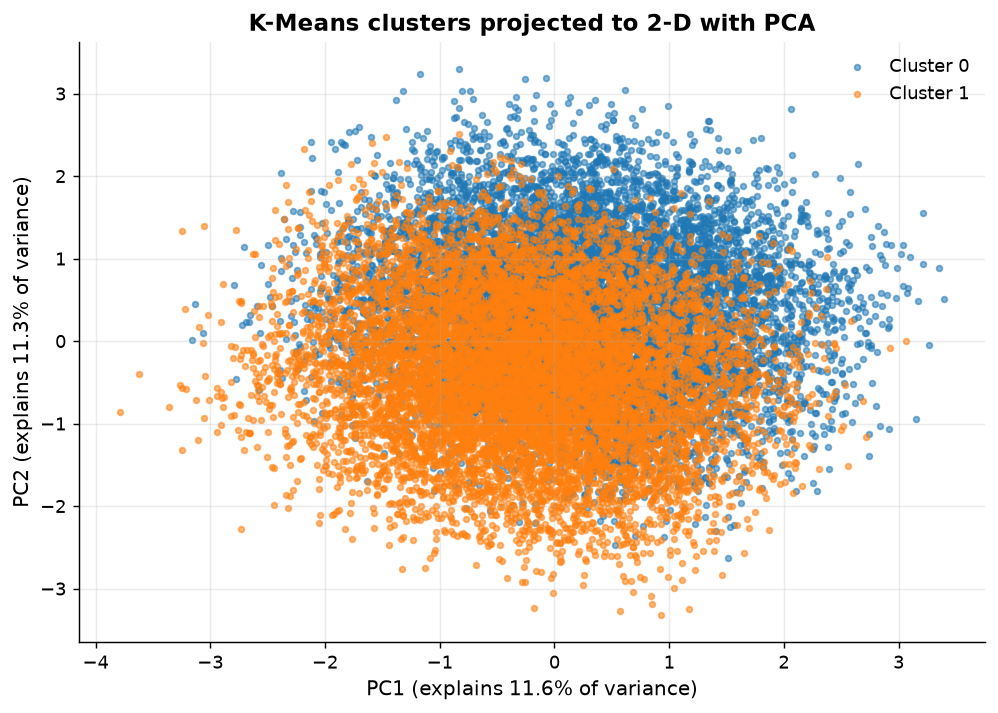

In [11]:
pcs = KM.pca_projection(X)
expl = pcs.attrs["explained_variance_ratio"]
print(f"PC1 explains {100*expl[0]:.1f}% and PC2 {100*expl[1]:.1f}% "
      f"-> {(pcs.shape[1])} of {X.shape[1]} dimensions, "
      f"{100*sum(expl):.1f}% of the total variance in the feature space")
display(pcs.attrs["components"].round(3))
feat = feat.merge(pcs, left_index=True, right_index=True)
paths = F.clustering(pcs, pd.Series(model.labels_, index=X.index),
                     profile, centroids_raw, polls)
Image(paths["02_pca_clusters"])

**PCA caveat that must appear in the report:** the 2-D picture keeps only
the percentage of variance printed above. Distances in the plot are **not**
distances in the original pollutant space, so the plot is illustrative and the
centroid table above is the authoritative description.

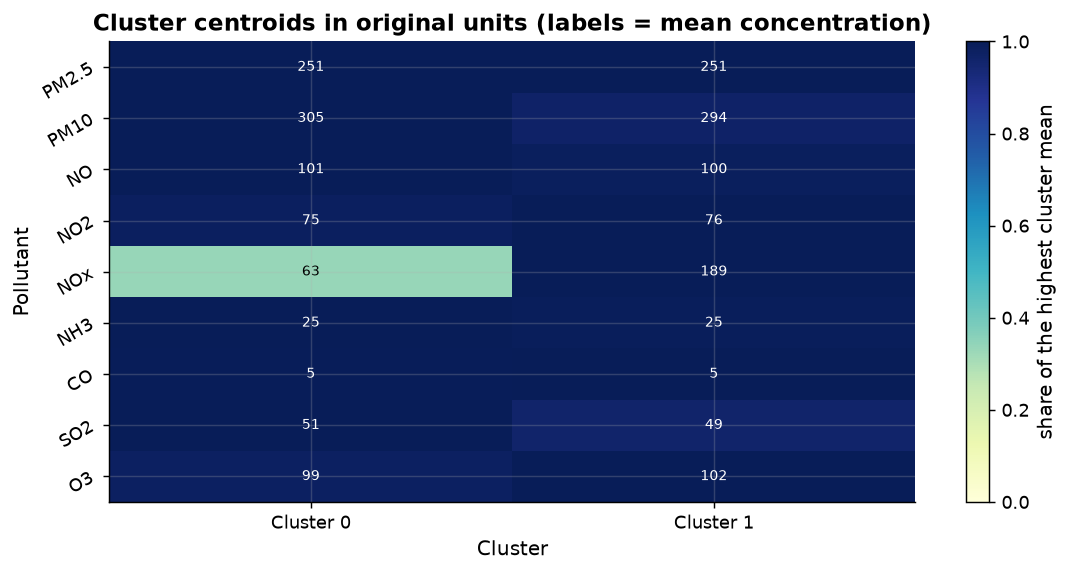

In [12]:
Image(paths["03_cluster_sizes_profiles"])
Image(paths["04_cluster_centroids"])

## 7. Which cities and AQI bands fall in which cluster?

In [13]:
ct = pd.crosstab(feat[C.CITY_COL], feat["Cluster"], normalize="index").mul(100).round(1)
display(ct)
print("If cities were genuinely different pollution profiles, these row percentages "
      "would differ strongly between cities.")

Cluster,0,1
City,,
Bangalore,50.0,50.0
Chennai,48.5,51.5
Delhi,51.3,48.7
Kolkata,49.7,50.3
Mumbai,50.0,50.0


If cities were genuinely different pollution profiles, these row percentages would differ strongly between cities.


In [14]:
keep = [c for c in [C.CITY_COL, "Date", "Year", "Season"] + polls +
          [C.AQI_COL, C.TARGET_COL, "Cluster", "PC1", "PC2"] if c in feat.columns]
feat[keep].to_csv(C.CLUSTER_RESULTS_CSV, index=False)
print("saved:", C.CLUSTER_RESULTS_CSV.name)

saved: cluster_results.csv


## Verification checklist

- [x] Features standardised before distance computation
- [x] K selected by a rule stated in advance, with the elbow reported too
- [x] Cluster profile table in original units, not only in z-scores
- [x] Descriptions kept neutral and numeric
- [x] Variance explained and seed stability measured
- [x] PCA limitation written down

**Common errors**

| Error | Meaning | Fix |
|---|---|---|
| `ValueError: Number of labels=... does not match number of samples` | silhouette on a subsample | `choose_k` subsamples consistently; re-run the cell |
| All points in one cluster | degenerate start | `n_init=10` is already set; check for a constant column |

**Next:** `07_anomaly_detection.ipynb`.